# CausalPy-Inspired Panel Methods For Marketing

This notebook adapts several CausalPy example families to marketing and
commercial analytics:

1. Interrupted time series for a national campaign with no control market.
2. Multi-geo synthetic control for a treated-region campaign.
3. Difference-in-differences for a regional store rollout.

The implementation uses pandas, statsmodels, scikit-learn, and scipy so it runs
in the core June cohort environment. The CausalPy examples are the reference
implementation for teams that want to port the same designs into CausalPy or
PyMC.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.optimize import minimize

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 11

rng = np.random.default_rng(42)


def find_data_path(filename):
    candidates = [
        Path("data") / filename,
        Path("../../data") / filename,
        Path("../../../data") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename}")


## 1. Interrupted Time Series: National TV Promo Lift

Use this design when the campaign went national and there is no untreated market
to serve as a clean control. The model learns the pre-campaign baseline and
projects the counterfactual into the campaign window.

Marketing translation: estimate the incremental revenue from a short national TV
promo flight. The TV promo spend is not included as a predictor because it is
the intervention whose total effect we want to estimate.

### Method Explanation

Interrupted time series has three moving pieces:

1. A treated time series, such as weekly revenue.
2. A known interruption date or campaign window.
3. A pre-period model that predicts the untreated baseline.

The model is fit only on the pre-campaign period. During the campaign period,
we compare observed revenue with the predicted counterfactual. If observed
revenue sits above the counterfactual, the gap is the estimated lift.

The counterfactual is credible only if the pre-period model captures the normal
structure of the business. In this notebook, the baseline includes a time trend,
month effects, price, competitor spend, search spend, and social spend. In a
real project, those controls should be chosen because they would still have
affected revenue if the TV promo had not run.

Read the output as:

- `estimated_incremental_revenue`: total observed revenue minus total predicted
  counterfactual revenue during the campaign.
- `estimated_relative_lift`: incremental revenue divided by counterfactual
  revenue.
- `conservative_lower_lift` and `conservative_upper_lift`: a rough interval
  using prediction bounds rather than one precise lift number.

Before using an ITS estimate, check pre-period residuals, seasonality, missing
business events, and whether another intervention started near the same date.


In [2]:
weeks = pd.date_range("2021-01-04", periods=156, freq="W-MON")
t = np.arange(len(weeks))

price_index = 100 + np.cumsum(rng.normal(0.02, 0.18, len(weeks)))
competitor_spend = 75_000 + 6_000 * np.sin(2 * np.pi * t / 26) + rng.normal(0, 4_500, len(weeks))
search_spend = 42_000 + 6_500 * np.sin(2 * np.pi * t / 52 + 0.8) + rng.normal(0, 2_500, len(weeks))
social_spend = 28_000 + 4_000 * np.cos(2 * np.pi * t / 13) + rng.normal(0, 2_000, len(weeks))

promo_start = pd.Timestamp("2023-03-06")
promo_end = pd.Timestamp("2023-04-24")
promo_period = (weeks >= promo_start) & (weeks <= promo_end)
tv_promo_spend = np.where(promo_period, rng.normal(95_000, 7_500, len(weeks)), 0)

seasonality = 420 * np.sin(2 * np.pi * t / 52) + 260 * np.cos(2 * np.pi * t / 26)
baseline_revenue = (
    6_500
    + 18 * t
    + seasonality
    - 34 * (price_index - 100)
    - 0.006 * competitor_spend
    + 0.019 * search_spend
    + 0.014 * social_spend
)

true_lift = np.where(promo_period, 0.085 * baseline_revenue + 0.0022 * tv_promo_spend, 0)
revenue = baseline_revenue + true_lift + rng.normal(0, 240, len(weeks))

its_df = pd.DataFrame(
    {
        "date": weeks,
        "t": t,
        "month": weeks.month,
        "revenue": revenue,
        "price_index": price_index,
        "competitor_spend": competitor_spend,
        "search_spend": search_spend,
        "social_spend": social_spend,
        "tv_promo_spend": tv_promo_spend,
        "promo_period": promo_period.astype(int),
        "true_lift": true_lift,
    }
)

its_df.head()


,date,t,month,revenue,price_index,competitor_spend,search_spend,social_spend,tv_promo_spend,promo_period,true_lift
0,2021-01-04,0,1,7740.048594,100.074849,75586.235347,51022.650906,34211.986740,0.0,0,0.0
1,2021-01-11,1,1,7651.743750,99.907652,80858.221785,48272.161960,29617.641870,0.0,0,0.0
2,2021-01-18,2,1,8220.251363,100.062733,75541.508839,49681.055503,30967.675892,0.0,0,0.0
3,2021-01-25,3,1,7946.322379,100.252035,73646.489001,47224.241421,27667.990248,0.0,0,0.0
4,2021-02-01,4,2,7750.522156,99.920848,75594.877765,48399.624203,26012.852776,0.0,0,0.0


In [3]:
pre_df = its_df[its_df["date"] < promo_start].copy()
campaign_df = its_df[its_df["promo_period"].eq(1)].copy()

its_model = smf.ols(
    "revenue ~ t + C(month) + price_index + competitor_spend + search_spend + social_spend",
    data=pre_df,
).fit(cov_type="HC1")

prediction = its_model.get_prediction(campaign_df).summary_frame(alpha=0.05)
campaign_df["counterfactual"] = prediction["mean"].to_numpy()
campaign_df["counterfactual_lower"] = prediction["obs_ci_lower"].to_numpy()
campaign_df["counterfactual_upper"] = prediction["obs_ci_upper"].to_numpy()
campaign_df["estimated_lift"] = campaign_df["revenue"] - campaign_df["counterfactual"]

observed_sum = campaign_df["revenue"].sum()
counterfactual_sum = campaign_df["counterfactual"].sum()
summary_its = pd.Series(
    {
        "observed_revenue": observed_sum,
        "counterfactual_revenue": counterfactual_sum,
        "estimated_incremental_revenue": observed_sum - counterfactual_sum,
        "conservative_lower_lift": observed_sum - campaign_df["counterfactual_upper"].sum(),
        "conservative_upper_lift": observed_sum - campaign_df["counterfactual_lower"].sum(),
        "estimated_relative_lift": (observed_sum / counterfactual_sum) - 1,
        "true_incremental_revenue_in_simulation": campaign_df["true_lift"].sum(),
    }
)

summary_its.to_frame("value")


,value
observed_revenue,84498.574611
counterfactual_revenue,75804.069692
estimated_incremental_revenue,8694.504920
conservative_lower_lift,4222.085238
conservative_upper_lift,13166.924601
estimated_relative_lift,0.114697
true_incremental_revenue_in_simulation,8132.051467


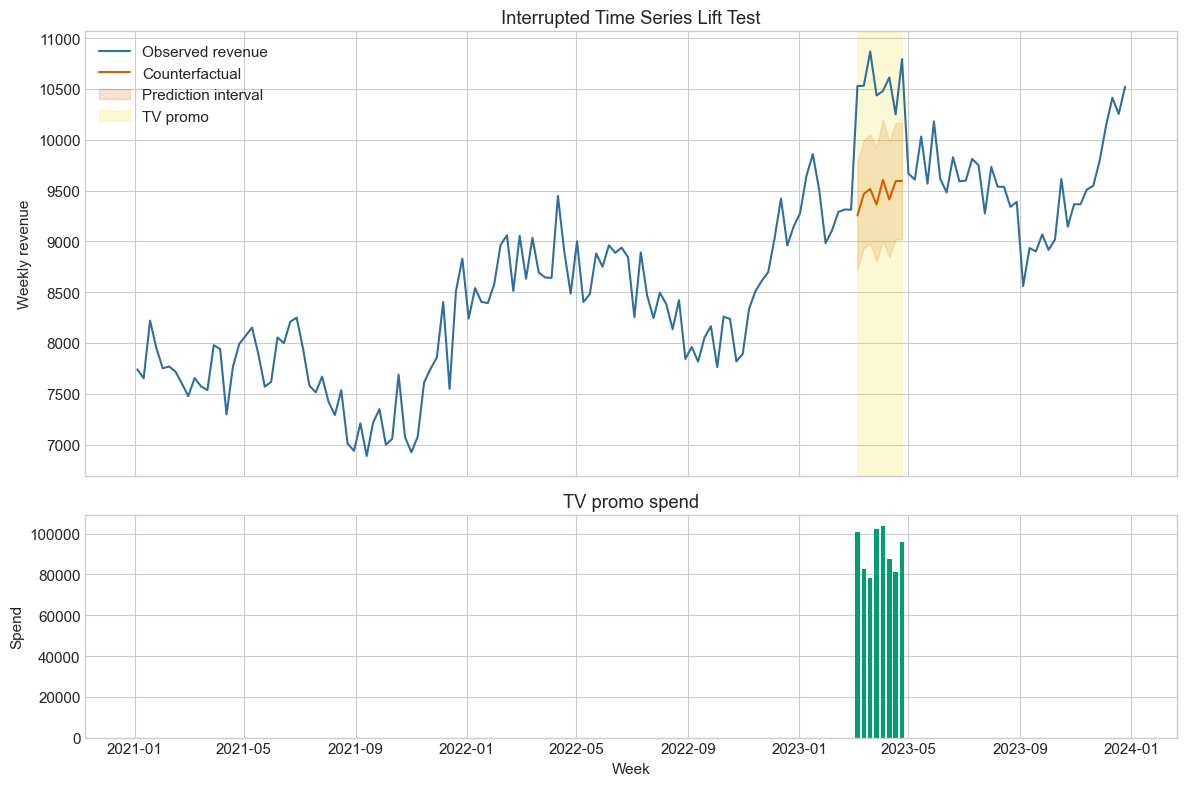

In [4]:
plot_df = its_df.merge(
    campaign_df[["date", "counterfactual", "counterfactual_lower", "counterfactual_upper"]],
    on="date",
    how="left",
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(plot_df["date"], plot_df["revenue"], label="Observed revenue", color="#2E6F9E")
axes[0].plot(campaign_df["date"], campaign_df["counterfactual"], label="Counterfactual", color="#D55E00")
axes[0].fill_between(
    campaign_df["date"],
    campaign_df["counterfactual_lower"],
    campaign_df["counterfactual_upper"],
    color="#D55E00",
    alpha=0.18,
    label="Prediction interval",
)
axes[0].axvspan(promo_start, promo_end, color="#F0E442", alpha=0.22, label="TV promo")
axes[0].set_title("Interrupted Time Series Lift Test")
axes[0].set_ylabel("Weekly revenue")
axes[0].legend(loc="upper left")

axes[1].bar(plot_df["date"], plot_df["tv_promo_spend"], width=5, color="#009E73")
axes[1].set_title("TV promo spend")
axes[1].set_ylabel("Spend")
axes[1].set_xlabel("Week")

plt.tight_layout()
plt.show()


## 2. Multi-Geo Synthetic Control: Regional Campaign Lift

Use this design when one or more geos received a campaign and the remaining
geos can be used as donors. Here we use the course's synthetic multi-geo MMM
dataset, add a known treatment effect after a campaign launch date, and recover
the average effect across treated geos.

Marketing translation: estimate the average lift per treated geo for a regional
media push before deciding whether to roll it out nationally.

### Method Explanation

Synthetic control asks: can a weighted blend of untreated geos reproduce the
treated geos before treatment? If yes, that same weighted blend becomes the
post-treatment counterfactual.

The fitting step chooses non-negative donor weights that sum to one. A high
weight means that donor geo helps match the treated geos' pre-period behavior.
A zero weight means that donor did not help the match. The weights are not a
media-mix allocation or a similarity score; they are only the recipe for the
counterfactual.

The main estimate is the post-period gap:

```text
lift_t = observed_treated_revenue_t - synthetic_control_revenue_t
```

Cumulative lift sums that gap over all post-treatment weeks. Relative lift
divides the treated post-period total by the synthetic post-period total and
subtracts one.

Trust depends heavily on pre-period fit. If the synthetic control misses the
treated series before the campaign, it has not earned the right to be used
after the campaign. The notebook reports pre-period MAPE and runs placebo
checks on donor geos to show whether similar gaps can appear even without
treatment.


In [5]:
geo_df = pd.read_csv(find_data_path("synthetic_multi_geo_data.csv"), parse_dates=["date"])

treated_geos = ["west", "northeast"]
control_geos = sorted(set(geo_df["geo"]) - set(treated_geos))
treatment_start = pd.Timestamp("2023-07-03")

geo_df["observed_revenue"] = geo_df["revenue"]
weeks_after_start = ((geo_df["date"] - treatment_start).dt.days / 7).clip(lower=0)
treated_post = geo_df["geo"].isin(treated_geos) & (geo_df["date"] >= treatment_start)
geo_df.loc[treated_post, "observed_revenue"] += (
    0.075 * geo_df.loc[treated_post, "revenue"]
    + 18 * np.exp(-weeks_after_start.loc[treated_post] / 10)
    + rng.normal(0, 8, treated_post.sum())
)

panel = geo_df.pivot(index="date", columns="geo", values="observed_revenue").sort_index()
pre_mask = panel.index < treatment_start
post_mask = panel.index >= treatment_start

treated_average = panel[treated_geos].mean(axis=1)
control_panel = panel[control_geos]

print(f"Treated geos: {treated_geos}")
print(f"Control geos: {control_geos}")
print(f"Pre-period weeks: {pre_mask.sum()}")
print(f"Test-period weeks: {post_mask.sum()}")


Treated geos: ['west', 'northeast']
Control geos: ['midwest', 'southeast', 'southwest']
Pre-period weeks: 78
Test-period weeks: 26


In [6]:
def fit_synthetic_control(y_pre, X_pre):
    n_controls = X_pre.shape[1]
    initial_weights = np.repeat(1 / n_controls, n_controls)

    def objective(weights):
        residuals = y_pre - X_pre @ weights
        return np.mean(residuals ** 2)

    constraints = {"type": "eq", "fun": lambda weights: weights.sum() - 1}
    bounds = [(0, 1) for _ in range(n_controls)]
    result = minimize(objective, initial_weights, method="SLSQP", bounds=bounds, constraints=constraints)
    if not result.success:
        raise RuntimeError(result.message)
    return result.x

weights = fit_synthetic_control(
    treated_average.loc[pre_mask].to_numpy(),
    control_panel.loc[pre_mask].to_numpy(),
)

counterfactual = pd.Series(control_panel.to_numpy() @ weights, index=panel.index, name="counterfactual")
effect = treated_average - counterfactual

pre_mape = np.mean(
    np.abs((treated_average.loc[pre_mask] - counterfactual.loc[pre_mask]) / treated_average.loc[pre_mask])
)
post_lift = effect.loc[post_mask].sum()
post_relative_lift = treated_average.loc[post_mask].sum() / counterfactual.loc[post_mask].sum() - 1

synthetic_summary = pd.DataFrame(
    {
        "control_geo": control_geos,
        "weight": weights,
    }
).sort_values("weight", ascending=False)

print(f"Pre-period MAPE: {pre_mape:.2%}")
print(f"Cumulative estimated lift per treated geo: {post_lift:,.1f}")
print(f"Relative lift per treated geo: {post_relative_lift:.2%}")
synthetic_summary


Pre-period MAPE: 17.95%
Cumulative estimated lift per treated geo: 6,103.3
Relative lift per treated geo: 33.56%


,control_geo,weight
1,southeast,1.000000e+00
2,southwest,2.080121e-07
0,midwest,0.000000e+00


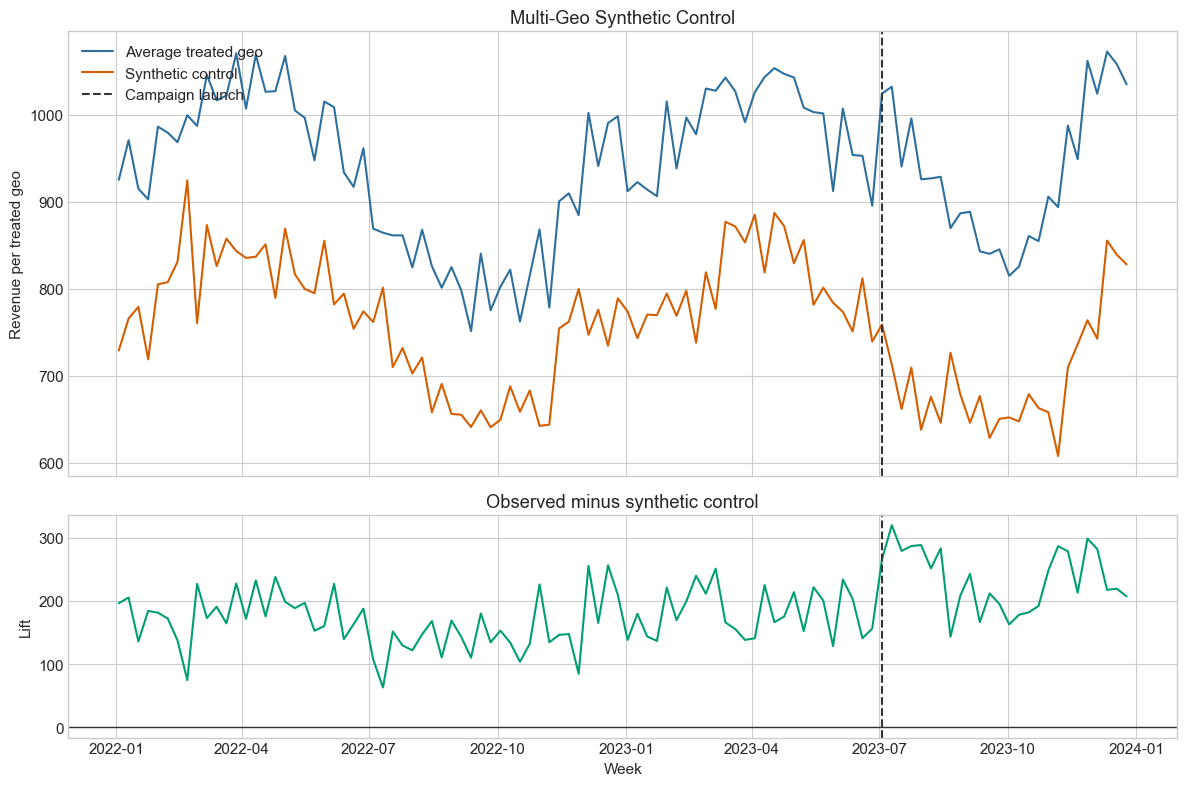

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(treated_average.index, treated_average, label="Average treated geo", color="#2E6F9E")
axes[0].plot(counterfactual.index, counterfactual, label="Synthetic control", color="#D55E00")
axes[0].axvline(treatment_start, color="#333333", linestyle="--", label="Campaign launch")
axes[0].set_title("Multi-Geo Synthetic Control")
axes[0].set_ylabel("Revenue per treated geo")
axes[0].legend(loc="upper left")

axes[1].plot(effect.index, effect, color="#009E73")
axes[1].axhline(0, color="#333333", linewidth=1)
axes[1].axvline(treatment_start, color="#333333", linestyle="--")
axes[1].set_title("Observed minus synthetic control")
axes[1].set_ylabel("Lift")
axes[1].set_xlabel("Week")
plt.tight_layout()
plt.show()


In [8]:
placebo_records = []

for placebo_geo in control_geos:
    donor_geos = [geo for geo in control_geos if geo != placebo_geo]
    placebo_y = panel[placebo_geo]
    placebo_X = panel[donor_geos]
    placebo_weights = fit_synthetic_control(
        placebo_y.loc[pre_mask].to_numpy(),
        placebo_X.loc[pre_mask].to_numpy(),
    )
    placebo_counterfactual = pd.Series(placebo_X.to_numpy() @ placebo_weights, index=panel.index)
    placebo_effect = placebo_y - placebo_counterfactual
    placebo_records.append(
        {
            "placebo_geo": placebo_geo,
            "pre_mape": np.mean(
                np.abs((placebo_y.loc[pre_mask] - placebo_counterfactual.loc[pre_mask]) / placebo_y.loc[pre_mask])
            ),
            "post_cumulative_gap": placebo_effect.loc[post_mask].sum(),
        }
    )

placebo_df = pd.DataFrame(placebo_records)
placebo_df["abs_post_cumulative_gap"] = placebo_df["post_cumulative_gap"].abs()
placebo_df.sort_values("abs_post_cumulative_gap", ascending=False)


,placebo_geo,pre_mape,post_cumulative_gap,abs_post_cumulative_gap
1,southeast,0.172872,3008.250000,3008.250000
2,southwest,0.090204,-1436.000000,1436.000000
0,midwest,0.039661,208.551504,208.551504


## 3. Difference-In-Differences: Regional Store Rollout

Use this design when a policy, sales motion, or commercial program rolls out to
some stores or regions while others remain untreated. The key check is whether
treated and control units had similar pre-treatment trends.

Marketing translation: estimate the revenue effect of a local loyalty offer
rolled out to selected stores.

### Method Explanation

Difference-in-differences compares changes, not levels. Treated stores may have
higher revenue than control stores before rollout, and that is acceptable if the
two groups would have followed parallel trends without treatment.

The simplest DiD calculation is:

```text
(treated_after - treated_before) - (control_after - control_before)
```

The regression version in this notebook is more flexible. Store fixed effects
control for persistent store differences, week fixed effects control for common
calendar shocks, and `treated_post` captures the extra post-rollout change for
treated stores. Standard errors are clustered by store because weekly outcomes
within a store are not independent.

The event-study plot is the most important diagnostic. Pre-rollout event-time
estimates should hover around zero. If treated stores already move away from
control stores before rollout, the parallel-trends assumption is weak and the
post-rollout estimate should not be treated as clean causal evidence.


In [9]:
n_stores = 80
n_weeks = 60
store_ids = [f"store_{i:03d}" for i in range(n_stores)]
weeks = np.arange(n_weeks)
rollout_week = 34

store_meta = pd.DataFrame(
    {
        "store_id": store_ids,
        "region": rng.choice(["north", "south", "east", "west"], size=n_stores),
        "store_size": rng.normal(0, 1, n_stores),
    }
)
store_meta["treated_store"] = 0
store_meta.loc[store_meta.sample(32, random_state=7).index, "treated_store"] = 1
store_meta["store_effect"] = 620 * store_meta["store_size"] + rng.normal(0, 260, n_stores)

rows = []
for _, store in store_meta.iterrows():
    for week in weeks:
        post = int(week >= rollout_week)
        treated_post = int(store["treated_store"] and post)
        seasonal = 240 * np.sin(2 * np.pi * week / 13)
        competition = rng.normal(0, 1)
        revenue = (
            8_800
            + store["store_effect"]
            + 24 * week
            + seasonal
            - 90 * competition
            + 430 * treated_post
            + rng.normal(0, 360)
        )
        rows.append(
            {
                "store_id": store["store_id"],
                "week": week,
                "region": store["region"],
                "treated_store": int(store["treated_store"]),
                "post": post,
                "treated_post": treated_post,
                "revenue": revenue,
            }
        )

did_df = pd.DataFrame(rows)
did_df.head()


,store_id,week,region,treated_store,post,treated_post,revenue
0,store_000,0,east,0,0,0,7255.746868
1,store_000,1,east,0,0,0,7125.369161
2,store_000,2,east,0,0,0,7566.118033
3,store_000,3,east,0,0,0,7699.150980
4,store_000,4,east,0,0,0,7947.895068


In [10]:
did_model = smf.ols(
    "revenue ~ treated_post + C(store_id) + C(week)",
    data=did_df,
).fit(cov_type="cluster", cov_kwds={"groups": did_df["store_id"]})

did_estimate = pd.Series(
    {
        "estimated_treatment_effect": did_model.params["treated_post"],
        "std_error": did_model.bse["treated_post"],
        "ci_lower": did_model.conf_int().loc["treated_post", 0],
        "ci_upper": did_model.conf_int().loc["treated_post", 1],
        "true_effect_in_simulation": 430.0,
    }
)

did_estimate.to_frame("value")


,value
estimated_treatment_effect,420.467460
std_error,25.815829
ci_lower,369.869364
ci_upper,471.065556
true_effect_in_simulation,430.000000


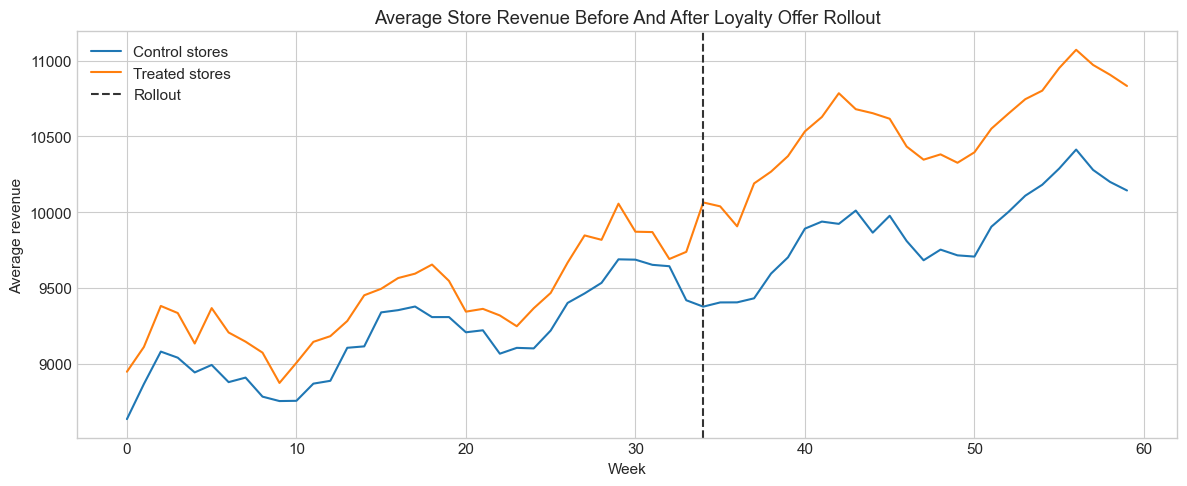

In [11]:
avg_trends = (
    did_df.groupby(["week", "treated_store"], as_index=False)["revenue"]
    .mean()
    .assign(group=lambda x: np.where(x["treated_store"].eq(1), "Treated stores", "Control stores"))
)

fig, ax = plt.subplots(figsize=(12, 5))
for group, group_df in avg_trends.groupby("group"):
    ax.plot(group_df["week"], group_df["revenue"], label=group)
ax.axvline(rollout_week, color="#333333", linestyle="--", label="Rollout")
ax.set_title("Average Store Revenue Before And After Loyalty Offer Rollout")
ax.set_xlabel("Week")
ax.set_ylabel("Average revenue")
ax.legend()
plt.tight_layout()
plt.show()


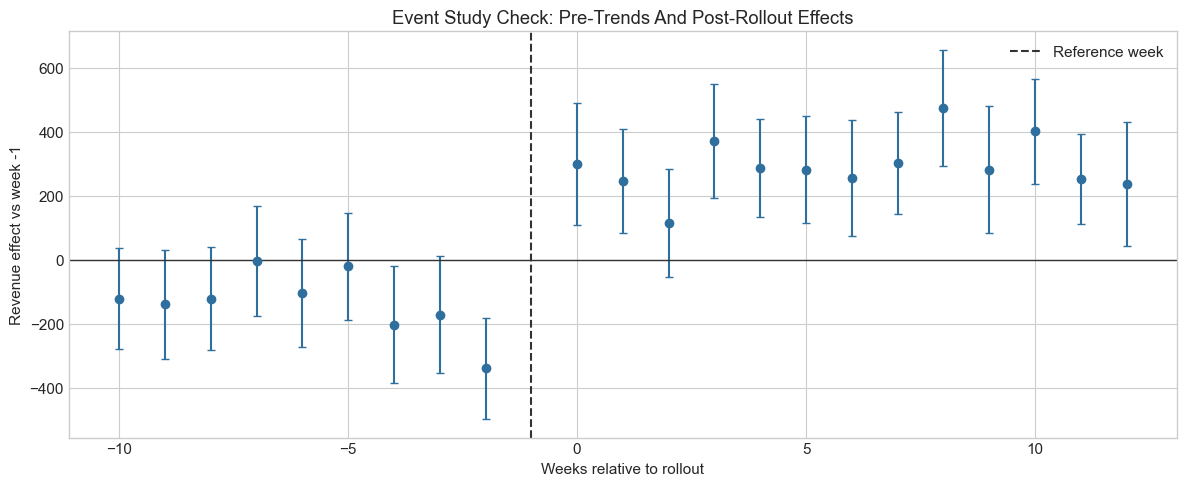

,relative_week,estimate,ci_lower,ci_upper
0,-10,-123.148376,-280.836737,34.539985
1,-9,-140.080668,-309.710132,29.548797
2,-8,-121.974685,-283.125675,39.176305
3,-7,-5.084991,-177.483302,167.313319
4,-6,-104.099632,-273.746386,65.547122
5,-5,-20.766643,-188.031423,146.498137
6,-4,-203.644121,-385.537287,-21.750955
7,-3,-171.874050,-353.977617,10.229518


In [12]:
event_terms = []
for rel_week in range(-10, 13):
    if rel_week == -1:
        continue
    column = f"event_{rel_week}".replace("-", "m")
    did_df[column] = ((did_df["treated_store"] == 1) & ((did_df["week"] - rollout_week) == rel_week)).astype(int)
    event_terms.append((rel_week, column))

event_formula = "revenue ~ " + " + ".join(column for _, column in event_terms) + " + C(store_id) + C(week)"
event_model = smf.ols(event_formula, data=did_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": did_df["store_id"]},
)

event_df = pd.DataFrame(
    {
        "relative_week": [rel_week for rel_week, _ in event_terms],
        "estimate": [event_model.params[column] for _, column in event_terms],
        "ci_lower": [event_model.conf_int().loc[column, 0] for _, column in event_terms],
        "ci_upper": [event_model.conf_int().loc[column, 1] for _, column in event_terms],
    }
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.errorbar(
    event_df["relative_week"],
    event_df["estimate"],
    yerr=[event_df["estimate"] - event_df["ci_lower"], event_df["ci_upper"] - event_df["estimate"]],
    fmt="o",
    color="#2E6F9E",
    ecolor="#2E6F9E",
    capsize=3,
)
ax.axhline(0, color="#333333", linewidth=1)
ax.axvline(-1, color="#333333", linestyle="--", label="Reference week")
ax.set_title("Event Study Check: Pre-Trends And Post-Rollout Effects")
ax.set_xlabel("Weeks relative to rollout")
ax.set_ylabel("Revenue effect vs week -1")
ax.legend()
plt.tight_layout()
plt.show()

event_df.head(8)


## Wrap-Up

Use the methods differently:

- Interrupted time series estimates lift for one treated time series when no
  control group exists.
- Synthetic control builds a counterfactual from donor markets and depends on
  pre-period fit.
- Difference-in-differences compares treated and control units before and after
  rollout and depends on parallel trends.

The estimate is only one deliverable. The stronger deliverable is a short causal
claim with the identifying assumption, validation checks, and calibration use.
